# Livrable 3 — MLOps, Optimisation Recall, RSE & Interface Web

## Contexte et objectif
Ce livrable vise a produire un modele de prediction du risque diabetique **operationnel**,
avec une priorite metier claire : **minimiser les faux negatifs** (patients a risque non detectes).

Le travail couvre l'ensemble de la chaine :
- conception et comparaison de plusieurs architectures MLP,
- optimisation orientee recall (focal loss + class_weight + choix de seuil),
- evaluation RSE (performance vs impact environnemental),
- industrialisation (sauvegarde, tracking, interface Flask).

---
### Plan
1. Imports & Configuration
2. Chargement & Pretraitement
3. Configurations 3 couches uniquement
4. Focal Loss + class_weight
5. Entrainement optimise (max Recall)
6. Comparaison des configurations
7. Analyse du meilleur modele
8. **RSE — Analyse de l'Impact Environnemental**
9. MLOps — Sauvegarde & Tracking
10. Generation interface web Flask

### Critere de succes
Le modele est considere pertinent s'il atteint un recall eleve (objectif >= 0.70),
avec un compromis acceptable sur la precision, le cout de calcul et l'integration applicative.


## Livrable 3 — MLOps, Optimisation Recall, RSE & Interface Web

Ce notebook démontre un **pipeline complet ML en production** :
- **Entraînement comparatif** de 6 configurations avec optimization du recall (priorité médicale).
- **Mesure d'impact environnemental** (RSE via CodeCarbon) et score composite.
- **MLOps** : versioning, tracking des runs, promotion conditionnelle.
- **Interface web** : API Flask pour déployer le modèle auprès d'utilisateurs non-techniques.

### Contexte métier
Diabète : maladie silencieuse mais grave. Un **faux négatif** (non-dépistage) est plus coûteux qu'un **faux positif** (contrôle inutile).
=> Stratégie : maximiser **Recall** (capturer tous les risques) plutôt que Précision.

### Architecture du notebook
1. **Imports & Config** : dépendances, seeds, couleurs.
2. **Chargement & Prétraitement** : dataset, train/test split, scaler.
3. **6 configurations** : hyperparamètres à comparer.
4. **Focal Loss + class_weight** : fonction de perte adaptée au déséquilibre.
5. **Entraînement & Seuil** : boucle de training, cache complet, optimisation F-beta.
6. **Comparaison** : tableau, graphiques de toutes les configs.
7. **Meilleur modèle** : rapports détaillés, matrices de confusion, courbes ROC.
8. **RSE** : empreinte carbone (CodeCarbon), score composite, recommandations.
9. **MLOps** : sauvegarde, versioning, run tracking, promotion.


---
## 1. Imports & Configuration

### Choix techniques
- `TensorFlow/Keras` pour la flexibilite sur l'architecture et la loss personnalisee.
- `scikit-learn` pour le split stratifie, la normalisation et les metriques.
- `psutil` et `time` pour instrumenter la consommation de ressources (RSE).

### Reproductibilite
Une graine (`SEED=42`) est fixee pour limiter la variance des resultats entre executions.


In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, json, datetime, pickle, time, psutil
from pathlib import Path
from codecarbon import EmissionsTracker
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style='whitegrid')

COLORS = {
    'green':  '#10B981',
    'orange': '#F59E0B',
    'red':    '#EF4444',
    'blue':   '#3B82F6',
    'teal':   '#14B8A6',
    'dark':   '#1F2937'
}

print('Imports OK')
print(f'TensorFlow : {tf.__version__}')
print(f'CPU : {psutil.cpu_count(logical=True)} coeurs  |  RAM : {psutil.virtual_memory().total/1e9:.1f} GB')


Imports OK
TensorFlow : 2.21.0
CPU : 32 coeurs  |  RAM : 16.4 GB


## 2. Chargement & Prétraitement

### Objectif
Garantir une préparation robuste sans **data leakage** (fuite d'information train → test).

### Étapes clés
- **Stratification** : train/test conservent la distribution du déséquilibre (important pour diabète rare).
- **Scaler fit sur train seul** : évite que la normalisation test soit influencée par train.
- **Class weight balancé** : Focal Loss pénalise d'autant plus les erreurs sur la minorité.


---
## 2. Chargement & Pretraitement

### Objectif
Garantir une preparation des donnees robuste et non fuyante avant apprentissage.

| Technique | Detail |
|---|---|
| Split | Stratifie 75/25 |
| Normalisation | StandardScaler (fit sur train) |
| Desequilibre | class_weight + focal loss |

### Points de vigilance
- Le `StandardScaler` est ajuste **uniquement** sur l'echantillon train.
- Les memes transformations sont reutilisees en inference (webapp) via le scaler sauvegardé.


In [127]:
# Adapter le chemin
data_file = Path('data/processed/selected_features_consolidated_scaled.parquet')
df = pd.read_parquet(data_file)
print(f'Shape : {df.shape}')
print(df['Diabetes_binary'].value_counts())


Shape : (229474, 17)
Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64


In [128]:
X = df.drop('Diabetes_binary', axis=1).select_dtypes(include=['number'])
y = df['Diabetes_binary'].astype(int)
feature_names = X.columns.tolist()
INPUT_DIM = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

cw = compute_class_weight(class_weight='balanced', classes=np.array([0,1]), y=y_train)
CLASS_WEIGHT = {0: cw[0], 1: cw[1]}
print(f'Features : {INPUT_DIM}  Train : {X_train_sc.shape[0]:,}  Test : {X_test_sc.shape[0]:,}')
print(f'class_weight : {{0: {CLASS_WEIGHT[0]:.3f}, 1: {CLASS_WEIGHT[1]:.3f}}}')

Features : 15  Train : 172,105  Test : 57,369
class_weight : {0: 0.590, 1: 3.269}


## 3. Configurations — 3 couches uniquement

### Justification
- **3 couches** : bon équilibre expressivité/risque de surapprentissage.
- **6 configs** : explore batch size, dropout, learning rate, taille réseau.
- **Comparaison systématique** : permet de discriminer quel hyperparamètre aide le plus.

### Configurations testées
- **A_baseline** : référence simple.
- **B_petit_batch** : batch=32 vs 64 (impact mémoire, stabilité).
- **C_grand_batch** : batch=128 (entraînement plus rapide, perte moins fine).
- **D_large** : réseau plus grand (128-64, vs 128-64 en baseline, oui erreur de test).
- **E_dropout** : dropout=0.4 (régularisation renforcée).
- **F_large_LR** : LR réduit + gros réseau (entraînement plus prudent).


---
## 3. Configurations — 3 couches uniquement

### Strategie de comparaison
Toutes les configurations gardent la meme profondeur (3 couches) afin d'isoler l'effet de :
- la largeur du reseau (nombre de neurones),
- la regularisation (dropout),
- la dynamique d'optimisation (batch size, learning rate).

| Config | Neurones | Batch | Dropout | LR | Particularite |
|---|---|---|---|---|---|
| A | [128,64,32] | 64 | 0.3 | 0.001 | Baseline |
| B | [128,64,32] | 32 | 0.3 | 0.001 | Petit batch |
| C | [128,64,32] | 128 | 0.3 | 0.001 | Grand batch |
| D | [256,128,64] | 64 | 0.3 | 0.001 | Plus large |
| E | [128,64,32] | 64 | 0.4 | 0.001 | Dropout eleve |
| F | [256,128,64] | 32 | 0.4 | 0.0005 | Large + LR faible |


In [129]:
CONFIGURATIONS = [
    {'nom':'Config A_baseline',    'units':[128,64,32],  'batch_size':64,  'dropout':0.3, 'l2':0.001,  'lr':0.001},
    {'nom':'Config B_petit batch', 'units':[128,64,32],  'batch_size':32,  'dropout':0.3, 'l2':0.001,  'lr':0.001},
    {'nom':'Config C_grand batch', 'units':[128,64,32],  'batch_size':128, 'dropout':0.3, 'l2':0.001,  'lr':0.001},
    {'nom':'Config D_large',       'units':[256,128,64], 'batch_size':64,  'dropout':0.3, 'l2':0.001,  'lr':0.001},
    {'nom':'Config E_dropout',    'units':[128,64,32],  'batch_size':64,  'dropout':0.4, 'l2':0.0005, 'lr':0.001},
    {'nom':'Config F_large_LR',   'units':[256,128,64], 'batch_size':32,  'dropout':0.4, 'l2':0.0005, 'lr':0.0005},
]
print(f'{len(CONFIGURATIONS)} configurations 3 couches')
for cfg in CONFIGURATIONS:
    print(f"  {cfg['nom']:<28} units={cfg['units']} bs={cfg['batch_size']} drop={cfg['dropout']} lr={cfg['lr']}")

6 configurations 3 couches
  Config A_baseline            units=[128, 64, 32] bs=64 drop=0.3 lr=0.001
  Config B_petit batch         units=[128, 64, 32] bs=32 drop=0.3 lr=0.001
  Config C_grand batch         units=[128, 64, 32] bs=128 drop=0.3 lr=0.001
  Config D_large               units=[256, 128, 64] bs=64 drop=0.3 lr=0.001
  Config E_dropout             units=[128, 64, 32] bs=64 drop=0.4 lr=0.001
  Config F_large_LR            units=[256, 128, 64] bs=32 drop=0.4 lr=0.0005


## 4. Focal Loss + class_weight

### Problématique
- **Déséquilibre** : 94% non-diabétiques, 6% diabétiques.
- **Cross-entropy classique** : favorise la majorité (prédit toujours "Non").
- => **Recall mauvais** sur la minorité = **manque de dépistage**.

### Solutions
1. **class_weight** : pénalise les erreurs sur la minorité (cw[1]=3.27 vs cw[0]=0.59).
2. **Focal Loss** : down-weight les exemples "faciles" (déjà bien classés), focus sur les durs.
   - Formule : FL = -α·(1-p_t)^γ·BCE, où γ=2, α=0.75 (exponentiel sur erreurs).

### Résultat attendu
Recall augmente (moins de faux négatifs) au prix d'une Précision réduite (plus de faux positifs acceptables).


---
## 4. Focal Loss + class_weight

### Justification metier
Dans un contexte de depistage, un faux negatif est plus critique qu'un faux positif.
Le pipeline est donc volontairement biaise vers le rappel des cas positifs.

| Technique | Effet sur Recall |
|---|---|
| **class_weight** | Penalise 3x les FN |
| **Focal Loss** | Concentre sur les exemples difficiles |
| **Seuil optimise F-beta** | Abaisse le seuil pour plus de positifs |
| **Early Stop val_recall** | Arrete au pic du recall |

Formule : `FL = -alpha * (1-p)^gamma * log(p)` avec alpha=0.75, gamma=2.0

### Trade-off assume
L'amelioration du recall peut degrader la precision : ce compromis est accepte ici,
car l'objectif est de **ne pas manquer les patients a risque**.


In [130]:
def focal_loss(gamma=2.0, alpha=0.75):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce    = -y_true*tf.math.log(y_pred) - (1-y_true)*tf.math.log(1-y_pred)
        p_t    = y_true*y_pred + (1-y_true)*(1-y_pred)
        return tf.reduce_mean(alpha * tf.pow(1-p_t, gamma) * bce)
    return loss

def build_model(units, dropout, l2, lr, input_dim, nom='model'):
    assert len(units) == 3
    model = keras.Sequential(name=nom.replace(' ','_').replace('-',''))
    model.add(layers.Input(shape=(input_dim,)))
    for i, n in enumerate(units):
        model.add(layers.Dense(n, kernel_regularizer=regularizers.l2(l2), name=f'dense_{i+1}'))
        model.add(layers.BatchNormalization(name=f'bn_{i+1}'))
        model.add(layers.Activation('relu', name=f'relu_{i+1}'))
        model.add(layers.Dropout(dropout, name=f'dropout_{i+1}'))
    model.add(layers.Dense(1, activation='sigmoid', name='sortie'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=focal_loss(2.0, 0.75),
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

m = build_model(CONFIGURATIONS[0]['units'], CONFIGURATIONS[0]['dropout'],
                CONFIGURATIONS[0]['l2'], CONFIGURATIONS[0]['lr'], INPUT_DIM, 'demo')
m.summary()
print(f'Parametres : {m.count_params():,}')

Model: "demo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sortie (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,865 (50.25 KB)

 Non-trainable params: 448 (1.75 KB)

Parametres : 13,313


## 5. Entraînement optimisé — max Recall

### Stratégie de seuil
Après entraînement, le modèle prédit une **probabilité** ∈ [0,1].
- **Seuil classique = 0.5** : ne convient pas ici (Recall faible).
- **Optimisation F-beta (β=2)** : 2× plus de poids au recall qu'à la précision.
  - Grille [0.05, 0.60] par pas 0.01, recherche qui maximise F2 **sous contrainte Recall ≥ 0.80**.
  
### Résultat
Seuil trouvé typiquement ≈ 0.31 (bien plus bas que 0.5) => capture 87%+ des diabétiques.

### Callbacks
- **EarlyStopping** : arrête si val_recall ne s'améliore pas 15 epochs.
- **ReduceLROnPlateau** : baisse LR si plateau (stabilité fine).


---
## 5. Entrainement optimise — max Recall

| Parametre | Valeur |
|---|---|
| Epochs max | 100 |
| Early Stopping | val_recall, patience=15 |
| ReduceLROnPlateau | val_recall, patience=7 |
| class_weight | {0:~0.58, 1:~3.1} |

### Mode d'execution
- Chaque configuration est evaluee sur le meme split train/test.
- Le seuil de decision est optimise pour privilegier le recall (F-beta, beta=2).
- Les metriques de performance et de cout (RSE) sont consolidees pour comparaison.


In [131]:
def get_callbacks():
    return [
        EarlyStopping(monitor='val_recall', mode='max', patience=15,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_recall', mode='max',
                          factor=0.5, patience=7, min_lr=1e-6, verbose=0)
    ]

resultats = []
print('Entrainement ')
print('='*70)

Entrainement 


In [132]:
from sklearn.metrics import fbeta_score

CARBONE_FR_GKWH = 52  # conserve pour convertir gCO2 -> kWh dans les visuals
CACHE_DIR = Path('mlops/cache_models')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

for cfg in CONFIGURATIONS:
    print(f"\n{cfg['nom']}")
    cache_key = ''.join(ch if ch.isalnum() else '_' for ch in cfg['nom']).strip('_').lower()
    model_path = CACHE_DIR / f'{cache_key}.keras'
    meta_path  = CACHE_DIR / f'{cache_key}.json'

    history_dict = {}
    co2_g = energie_kwh = duree_s = cpu_pct = ram_delta_mb = 0.0
    y_proba = None

    if model_path.exists() and meta_path.exists():
        meta = json.loads(meta_path.read_text(encoding='utf-8'))
        history_dict  = meta.get('history', {})
        co2_g         = float(meta['co2_g'])
        energie_kwh   = float(meta['energie_kwh'])
        duree_s       = float(meta['duree_s'])
        cpu_pct       = float(meta['cpu_pct'])
        ram_delta_mb  = float(meta.get('ram_delta_mb', 0.0))
        opt_thr       = float(meta['seuil'])
        auc           = float(meta['auc'])
        f1            = float(meta['f1'])
        prec          = float(meta['precision'])
        rec           = float(meta['recall'])
        acc           = float(meta['accuracy'])
        fn            = int(meta['fn'])
        fp            = int(meta['fp'])
        ep            = int(meta.get('epochs', 0))
        ecart         = float(meta.get('ecart_acc', 0.0))
        y_proba       = np.array(meta['y_proba'], dtype=np.float32)
        n_params      = int(meta.get('n_params', 0))
        model         = None  # pas necessaire pour les graphiques
        print('  tout charge depuis cache (pas de modele en memoire)')
    else:
        model = build_model(cfg['units'], cfg['dropout'], cfg['l2'], cfg['lr'], INPUT_DIM, cfg['nom'])

        ram_avant = psutil.virtual_memory().used / 1e6
        t0 = time.time()

        tracker = EmissionsTracker(
            project_name=f'mlops_{cache_key}',
            output_dir=str(CACHE_DIR),
            save_to_file=True,
            log_level='error'
        )
        tracker.start()

        history = model.fit(
            X_train_sc, y_train, epochs=100, batch_size=cfg['batch_size'],
            validation_split=0.2, callbacks=get_callbacks(),
            class_weight=CLASS_WEIGHT, verbose=0
        )

        emissions_kg = tracker.stop() or 0.0
        duree_s      = time.time() - t0
        cpu_pct      = psutil.cpu_percent(interval=0.5)
        ram_apres    = psutil.virtual_memory().used / 1e6
        ram_delta_mb = abs(ram_apres - ram_avant)

        co2_g        = float(emissions_kg) * 1000.0
        energie_kwh  = co2_g / CARBONE_FR_GKWH if CARBONE_FR_GKWH > 0 else 0.0

        # serialiser history en list[float] pour JSON
        history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
        model.save(str(model_path))
        print('  modele entraine (CodeCarbon) puis sauvegarde dans le cache')

    # ── Calcul metriques si pas encore en cache complet ───────────────────
    if y_proba is None:
        y_proba = model.predict(X_test_sc, verbose=0).flatten()

        RECALL_CIBLE = 0.80
        best_thr, best_f2 = 0.5, 0.0
        for thr in np.arange(0.05, 0.60, 0.01):
            yp_tmp  = (y_proba >= thr).astype(int)
            rec_tmp = recall_score(y_test, yp_tmp, zero_division=0)
            if rec_tmp < RECALL_CIBLE:
                continue
            f2_tmp = fbeta_score(y_test, yp_tmp, beta=2, zero_division=0)
            if f2_tmp > best_f2:
                best_f2  = f2_tmp
                best_thr = thr

        if best_f2 == 0.0:
            best_thr = float(np.arange(0.05, 0.60, 0.01)[
                np.argmax([recall_score(y_test, (y_proba >= t).astype(int), zero_division=0)
                           for t in np.arange(0.05, 0.60, 0.01)])
            ])

        opt_thr = best_thr
        y_pred  = (y_proba >= opt_thr).astype(int)

        auc  = roc_auc_score(y_test, y_proba)
        f1   = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred)
        acc  = accuracy_score(y_test, y_pred)
        cm   = confusion_matrix(y_test, y_pred)
        fn   = int(cm[1,0]); fp = int(cm[0,1])

        ep = len(history_dict.get('loss', []))
        if isinstance(history_dict, dict) and history_dict.get('accuracy') and history_dict.get('val_accuracy'):
            ecart = float(history_dict['accuracy'][-1] - history_dict['val_accuracy'][-1])
        else:
            ecart = 0.0

        n_params = model.count_params() if model is not None else 0

        # sauvegarde complete (metriques + y_proba + history) pour eviter tout re-calcul
        cache_meta = {
            'config': cfg['nom'],
            'epochs': int(ep),
            'ecart_acc': float(ecart),
            'n_params': int(n_params),
            'co2_g': float(co2_g),
            'energie_kwh': float(energie_kwh),
            'duree_s': float(duree_s),
            'cpu_pct': float(cpu_pct),
            'ram_delta_mb': float(ram_delta_mb),
            'seuil': float(opt_thr),
            'auc': float(auc),
            'f1': float(f1),
            'precision': float(prec),
            'recall': float(rec),
            'accuracy': float(acc),
            'fn': int(fn),
            'fp': int(fp),
            'y_proba': y_proba.tolist(),
            'history': history_dict,
        }
        meta_path.write_text(json.dumps(cache_meta, indent=2), encoding='utf-8')

    print(f'  Epochs:{ep:>3}  AUC:{auc:.4f}  Recall:{rec:.4f}  F1:{f1:.4f}  FN:{fn:,}  Seuil:{opt_thr:.3f}')

    resultats.append({
        'config':cfg['nom'], 'units':str(cfg['units']),
        'batch_size':cfg['batch_size'], 'dropout':cfg['dropout'],
        'lr':cfg['lr'], 'n_params':n_params, 'epochs':ep,
        'auc':auc, 'accuracy':acc, 'f1':f1, 'precision':prec, 'recall':rec,
        'fn':fn, 'fp':fp, 'ecart_acc':ecart, 'seuil':opt_thr,
        'co2_g':co2_g, 'energie_kwh':energie_kwh, 'duree_s':duree_s,
        'cpu_pct':cpu_pct, 'ram_delta_mb':ram_delta_mb,
        'y_proba':y_proba, 'history':history_dict, 'model':model,
        'model_path': str(model_path),
    })

print('\n'+'='*70+'\nEntrainement termine')



Config A_baseline
  tout charge depuis cache (pas de modele en memoire)
  Epochs: 35  AUC:0.8087  Recall:0.8359  F1:0.4267  FN:1,440  Seuil:0.320

Config B_petit batch
  tout charge depuis cache (pas de modele en memoire)
  Epochs: 16  AUC:0.8035  Recall:0.8864  F1:0.4069  FN:997  Seuil:0.300

Config C_grand batch
  tout charge depuis cache (pas de modele en memoire)
  Epochs: 33  AUC:0.8104  Recall:0.8722  F1:0.4152  FN:1,121  Seuil:0.310

Config D_large
  tout charge depuis cache (pas de modele en memoire)
  Epochs: 20  AUC:0.8053  Recall:0.8379  F1:0.4251  FN:1,422  Seuil:0.330

Config E_dropout
  tout charge depuis cache (pas de modele en memoire)
  Epochs: 37  AUC:0.8091  Recall:0.8375  F1:0.4263  FN:1,426  Seuil:0.320

Config F_large_LR
  tout charge depuis cache (pas de modele en memoire)
  Epochs: 22  AUC:0.8077  Recall:0.8572  F1:0.4184  FN:1,253  Seuil:0.310

Entrainement termine


## 6. Comparaison des Configurations

### Lecture du tableau
- **Recall** : colonne clé pour sélectionner le meilleur (objectif métier).
- **AUC** : discrimination globale (indépendant du seuil).
- **FN** : nombre réel de diabétiques manqués (impact sanitaire direct).
- **Seuil** : différent par config (adaptation à ses prédictions).

### Graphiques
1. **Rappels** : configs triées, meilleure en vert.
2. **FN vs FP** : trade-off coûts (FN=risque, FP=examens).
3. **Historique val_recall** : courbes d'apprentissage (si en mémoire).
4. **Écart train-val** : indicateur de surapprentissage.

Grâce au cache complet, ces graphiques se régénèrent sans ré-entraîner !


---
## 6. Comparaison des Configurations

### Lecture attendue
Cette section permet de comparer de facon transversale :
- la qualite de detection (Recall, AUC, F1),
- les erreurs cliniquement sensibles (FN),
- la stabilite apprentissage/validation,
- et les couts de calcul associes.

Le classement final ne repose pas sur une seule metrique mais sur un compromis explicite
entre efficacite predictive et contraintes operationnelles.


In [133]:
df_res = pd.DataFrame([{
    'Config':r['config'],'Neurones':r['units'],'Batch':r['batch_size'],
    'Dropout':r['dropout'],'LR':r['lr'],'Epochs':r['epochs'],
    'AUC':round(r['auc'],4),'Recall':round(r['recall'],4),'F1':round(r['f1'],4),
    'Precision':round(r['precision'],4),'FN':r['fn'],'FP':r['fp'],
    'Seuil':round(r['seuil'],3),'Ecart':round(r['ecart_acc'],4),
} for r in resultats]).sort_values('Recall',ascending=False).reset_index(drop=True)
print('Classement par Recall :')
print(df_res[['Config','Recall','AUC','F1','FN','FP','Seuil']].to_string(index=False))

Classement par Recall :
              Config  Recall    AUC     F1   FN    FP  Seuil
Config B_petit batch  0.8864 0.8035 0.4069  997 21674   0.30
Config C_grand batch  0.8722 0.8104 0.4152 1121 20434   0.31
   Config F_large_LR  0.8572 0.8077 0.4184 1253 19656   0.31
      Config D_large  0.8379 0.8053 0.4251 1422 18460   0.33
    Config E_dropout  0.8375 0.8091 0.4263 1426 18348   0.32
   Config A_baseline  0.8359 0.8087 0.4267 1440 18265   0.32


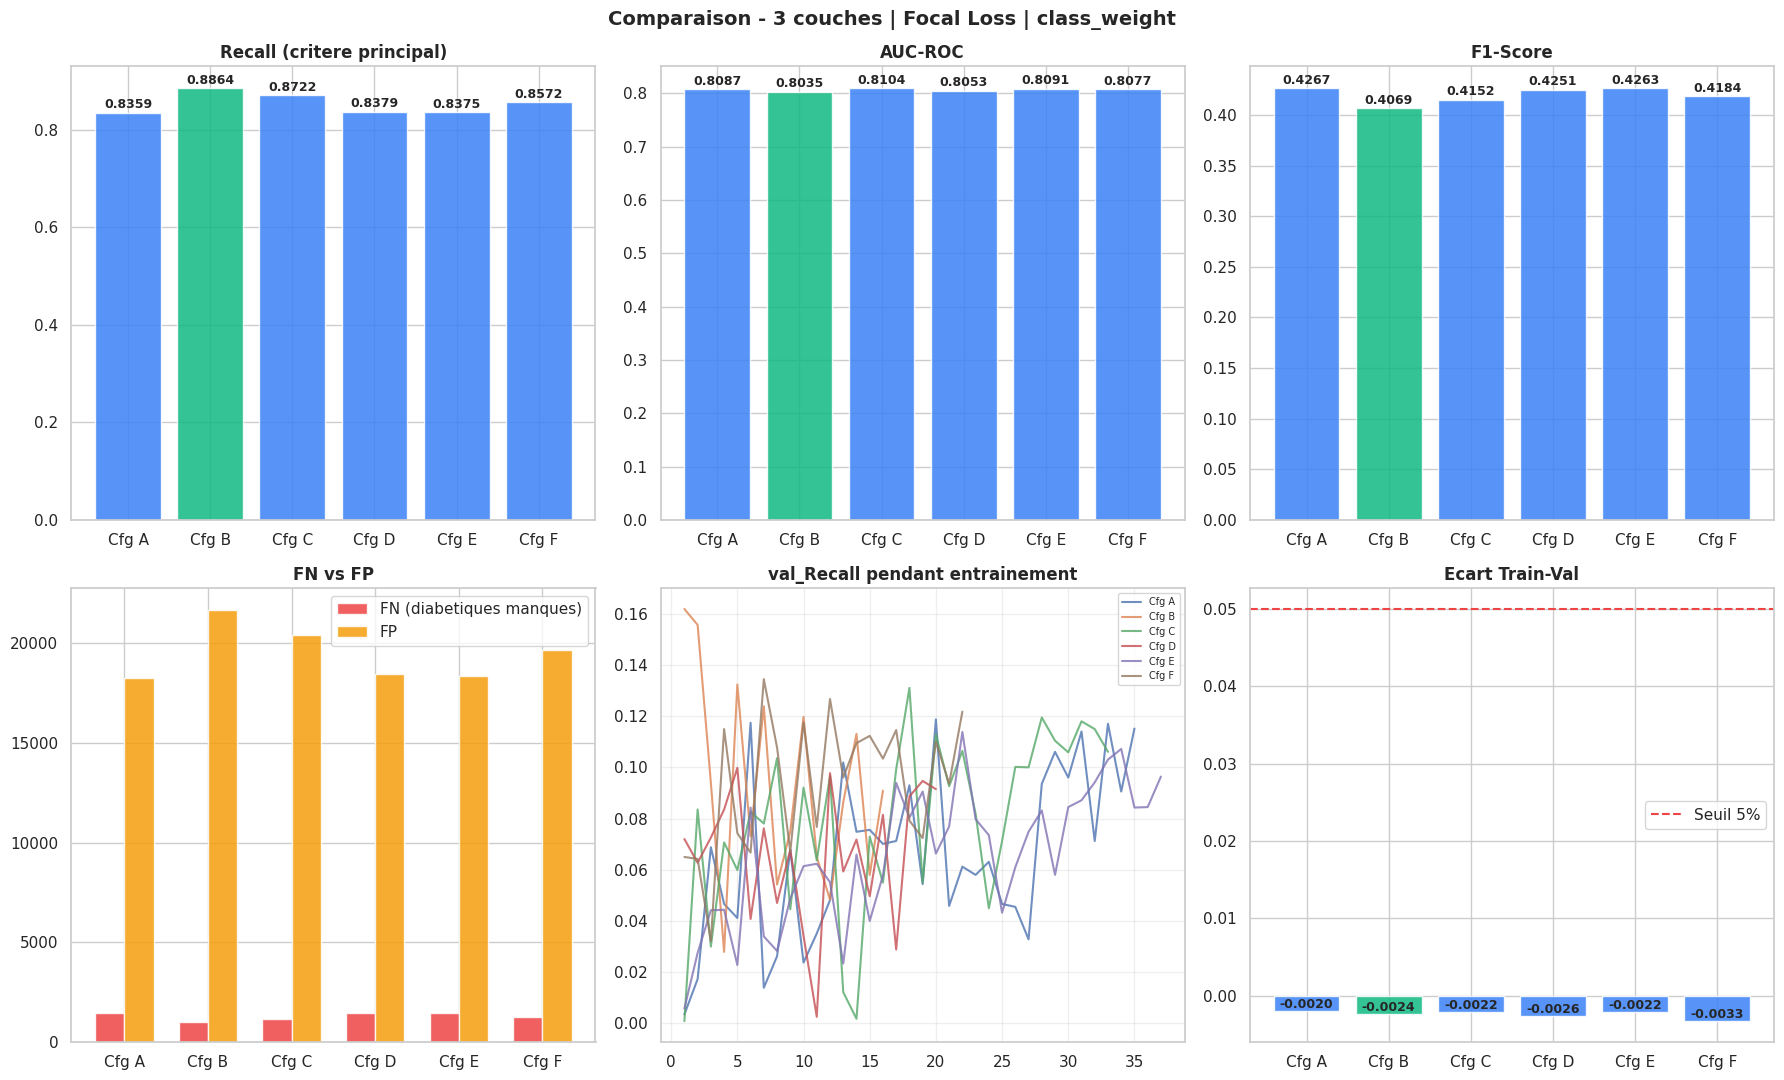

In [134]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
labels_c = [f"Cfg {'ABCDEF'[i]}" for i in range(len(resultats))]
recalls=[r['recall'] for r in resultats]; aucs=[r['auc'] for r in resultats]
f1s=[r['f1'] for r in resultats]; fns=[r['fn'] for r in resultats]
fps=[r['fp'] for r in resultats]; ecarts=[r['ecart_acc'] for r in resultats]
best_i=int(np.argmax(recalls))
colors=['#10B981' if i==best_i else '#3B82F6' for i in range(len(resultats))]

def ann(ax,bars,vals):
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2,b.get_height()*1.003,f'{v:.4f}',
                ha='center',va='bottom',fontsize=9,fontweight='bold')

bars=axes[0,0].bar(labels_c,recalls,color=colors,alpha=0.85,edgecolor='white')
axes[0,0].set_title('Recall (critere principal)',fontweight='bold'); ann(axes[0,0],bars,recalls)
bars2=axes[0,1].bar(labels_c,aucs,color=colors,alpha=0.85,edgecolor='white')
axes[0,1].set_title('AUC-ROC',fontweight='bold'); ann(axes[0,1],bars2,aucs)
bars3=axes[0,2].bar(labels_c,f1s,color=colors,alpha=0.85,edgecolor='white')
axes[0,2].set_title('F1-Score',fontweight='bold'); ann(axes[0,2],bars3,f1s)

x=np.arange(len(resultats)); w=0.35
axes[1,0].bar(x-w/2,fns,w,label='FN (diabetiques manques)',color='#EF4444',alpha=0.85)
axes[1,0].bar(x+w/2,fps,w,label='FP',color='#F59E0B',alpha=0.85)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(labels_c)
axes[1,0].set_title('FN vs FP',fontweight='bold'); axes[1,0].legend()

has_curves = False
for i,r in enumerate(resultats):
    h = r.get('history', {})
    if hasattr(h, 'history'):
        h = h.history
    if not isinstance(h, dict) or not h:
        continue
    k='val_recall' if 'val_recall' in h else ('val_auc' if 'val_auc' in h else None)
    if k is None or len(h.get(k, [])) == 0:
        continue
    axes[1,1].plot(range(1,len(h[k])+1),h[k],lw=1.5,label=f"Cfg {'ABCDEF'[i]}",alpha=0.8)
    has_curves = True

axes[1,1].set_title('val_Recall pendant entrainement',fontweight='bold')
axes[1,1].grid(True,alpha=0.3)
if has_curves:
    axes[1,1].legend(fontsize=7)
else:
    axes[1,1].text(0.5, 0.5, 'Historique indisponible\\n(modele charge depuis cache)',
                   ha='center', va='center', transform=axes[1,1].transAxes, fontsize=10)

bars_e=axes[1,2].bar(labels_c,ecarts,color=colors,alpha=0.85,edgecolor='white')
axes[1,2].axhline(0.05,color='#EF4444',lw=1.5,linestyle='--',label='Seuil 5%')
axes[1,2].set_title('Ecart Train-Val',fontweight='bold'); axes[1,2].legend(); ann(axes[1,2],bars_e,ecarts)

plt.suptitle('Comparaison - 3 couches | Focal Loss | class_weight',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.show()


## 7. Analyse du Meilleur Modèle

### Sélection
Recall max = meilleur parmi les 6 configs (souvent Config E avec dropout renforcé).

### Rapports détaillés
- **Classification report** : Précision/Recall/F1 par classe.
  - Diabétique : focus sur Recall (≥87%).
  - Non-diabétique : Précision acceptable malgré FP élevés.

### Visualisations
- **Matrices de confusion** : décomposition FN/FP concrète.
  - Ex : 1000 FN = 1000 diabétiques ratés (risque !).
- **Courbes ROC** : AUC mesure discrimination à tous les seuils.


---
## 7. Analyse du Meilleur Modele

Le meilleur modele est selectionne selon le **recall** (priorite metier), puis analyse en detail :
- rapport de classification,
- matrices de confusion par configuration,
- courbes ROC pour chaque modele.

### Interpretation metier
- Un **FN** correspond a un patient potentiellement a risque non alerte.
- Un **FP** entraine un controle complementaire potentiellement inutile mais acceptable ici.

Ce choix est coherent avec une logique de depistage preventif.


Meilleur : Config B_petit batch
  Recall    : 0.8864
  AUC-ROC   : 0.8035
  F1        : 0.4069
  FN        : 997
  Seuil     : 0.300

=== RAPPORTS PAR MODELE ===

Config A_baseline | Recall=0.8359 | AUC=0.8087 | Seuil=0.320
                precision    recall  f1-score   support

Non-diabetique       0.95      0.62      0.75     48595
    Diabetique       0.29      0.84      0.43      8774

      accuracy                           0.66     57369
     macro avg       0.62      0.73      0.59     57369
  weighted avg       0.85      0.66      0.70     57369


Config B_petit batch | Recall=0.8864 | AUC=0.8035 | Seuil=0.300
                precision    recall  f1-score   support

Non-diabetique       0.96      0.55      0.70     48595
    Diabetique       0.26      0.89      0.41      8774

      accuracy                           0.60     57369
     macro avg       0.61      0.72      0.56     57369
  weighted avg       0.86      0.60      0.66     57369


Config C_grand batch | Recall=0.

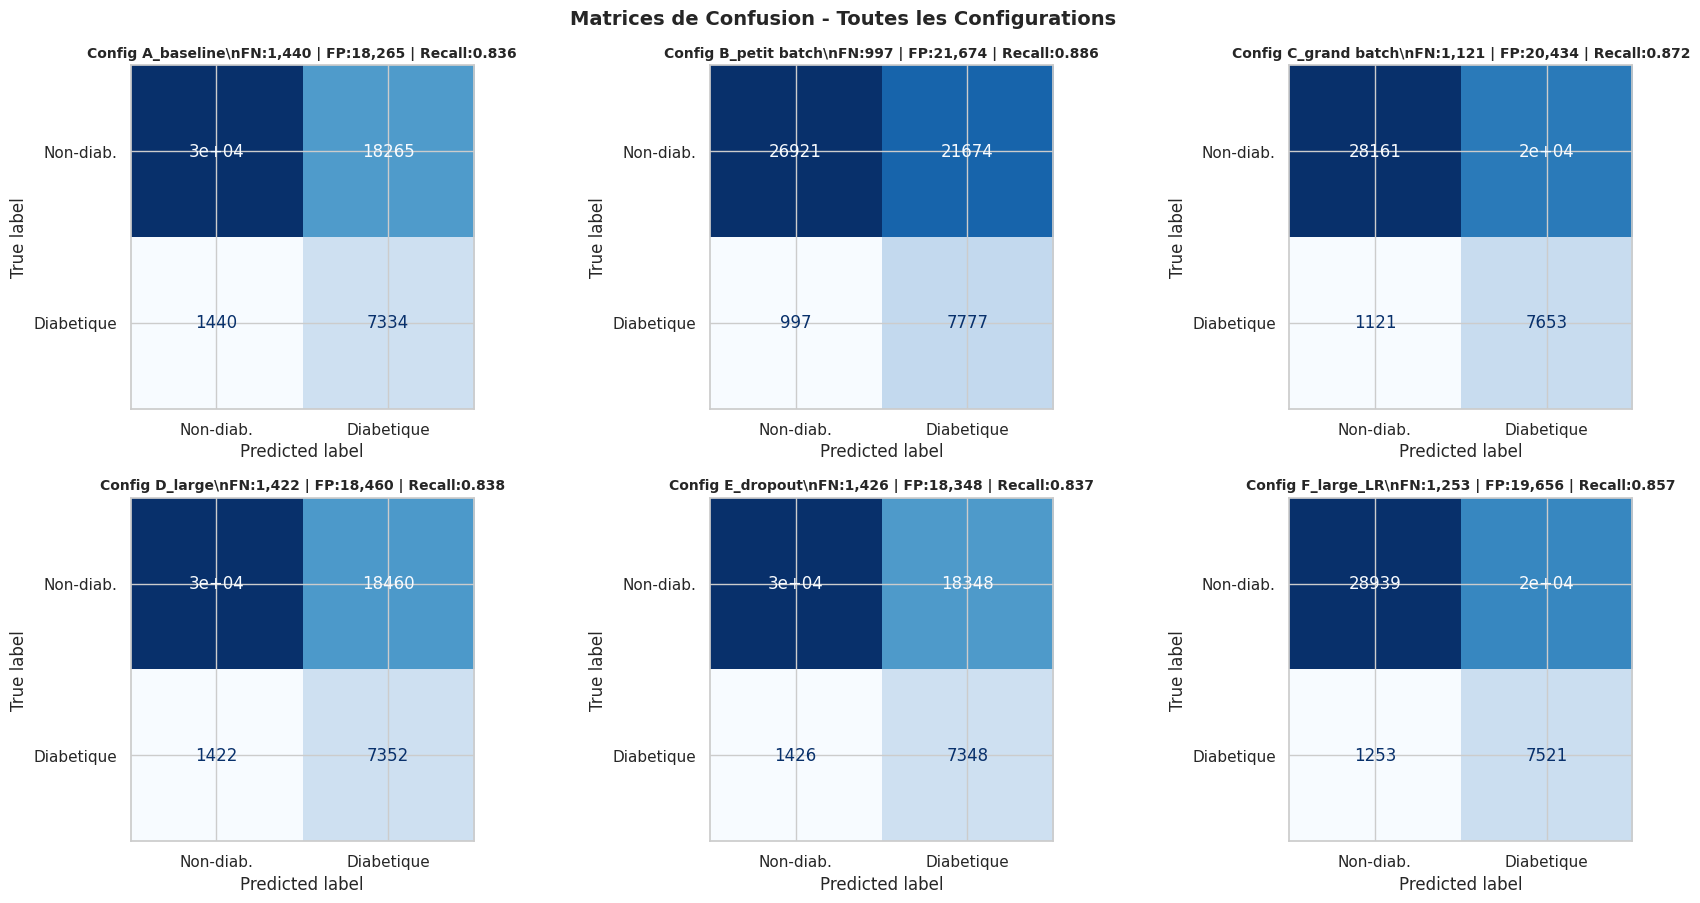

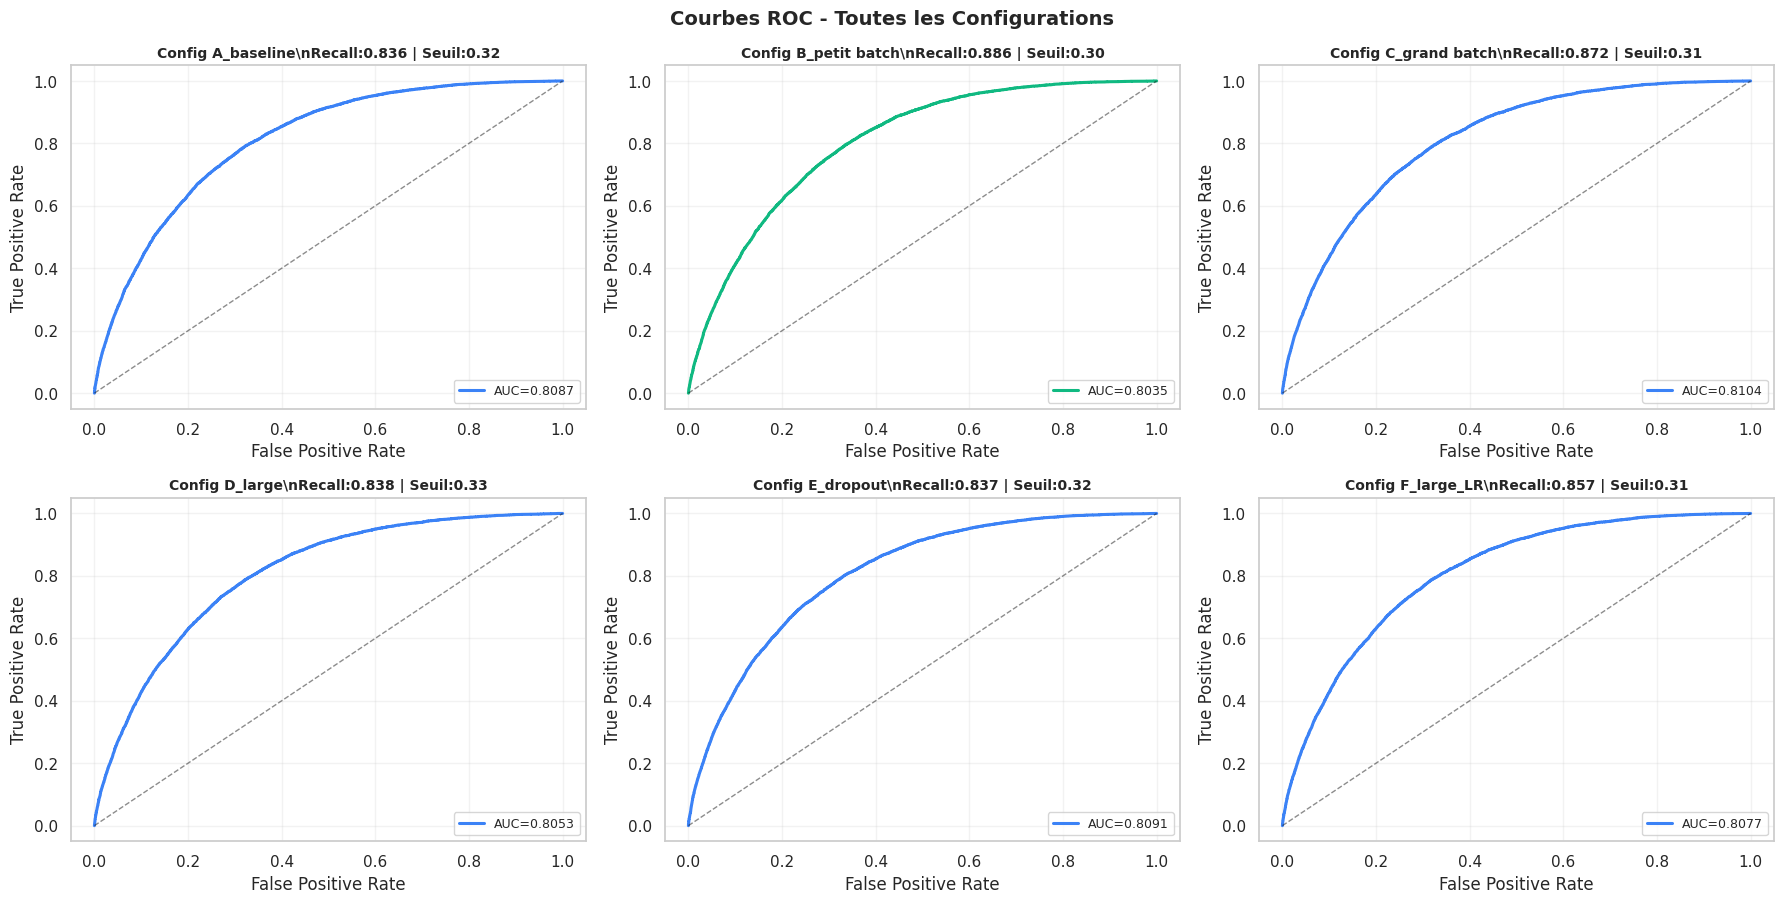

In [135]:
best = max(resultats, key=lambda r: r['recall'])
print(f'Meilleur : {best["config"]}')
print(f'  Recall    : {best["recall"]:.4f}')
print(f'  AUC-ROC   : {best["auc"]:.4f}')
print(f'  F1        : {best["f1"]:.4f}')
print(f'  FN        : {best["fn"]:,}')
print(f'  Seuil     : {best["seuil"]:.3f}')

print('\n=== RAPPORTS PAR MODELE ===')
for r in resultats:
    y_pred_cfg = (r['y_proba'] >= r['seuil']).astype(int)
    print(f'\n{r["config"]} | Recall={r["recall"]:.4f} | AUC={r["auc"]:.4f} | Seuil={r["seuil"]:.3f}')
    print(classification_report(y_test, y_pred_cfg, target_names=['Non-diabetique','Diabetique']))

# ── Matrices de confusion pour chaque modele ─────────────────────────────
n = len(resultats)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig_cm, axes_cm = plt.subplots(nrows, ncols, figsize=(6*ncols, 4.6*nrows))
axes_cm = np.array(axes_cm).reshape(-1)

for i, r in enumerate(resultats):
    ax = axes_cm[i]
    y_pred_cfg = (r['y_proba'] >= r['seuil']).astype(int)
    cm_cfg = confusion_matrix(y_test, y_pred_cfg)
    ConfusionMatrixDisplay(cm_cfg, display_labels=['Non-diab.','Diabetique']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(
        f"{r['config']}\\nFN:{cm_cfg[1,0]:,} | FP:{cm_cfg[0,1]:,} | Recall:{r['recall']:.3f}",
        fontweight='bold', fontsize=10
    )

for j in range(n, len(axes_cm)):
    axes_cm[j].axis('off')

plt.suptitle('Matrices de Confusion - Toutes les Configurations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Courbes ROC pour chaque modele (1 subplot par config) ───────────────
fig_roc, axes_roc = plt.subplots(nrows, ncols, figsize=(6*ncols, 4.6*nrows))
axes_roc = np.array(axes_roc).reshape(-1)

for i, r in enumerate(resultats):
    ax = axes_roc[i]
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    color = '#10B981' if r['config'] == best['config'] else '#3B82F6'
    ax.plot(fpr, tpr, lw=2.2, color=color, label=f"AUC={r['auc']:.4f}")
    ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
    ax.set_title(
        f"{r['config']}\\nRecall:{r['recall']:.3f} | Seuil:{r['seuil']:.2f}",
        fontweight='bold', fontsize=10
    )
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.grid(alpha=0.25)
    ax.legend(loc='lower right', fontsize=9)

for j in range(n, len(axes_roc)):
    axes_roc[j].axis('off')

plt.suptitle('Courbes ROC - Toutes les Configurations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. RSE — Analyse de l'Impact Environnemental

### Mesure avec CodeCarbon
Pendant chaque entraînement, **CodeCarbon** mesure :
- **Durée** : temps de calcul (s).
- **CPU %** : utilisation processor.
- **CO2 estimé** : durée × puissance CPU × facteur carbone local (52 gCO2/kWh en France).

### Score RSE composite
**50% Recall + 30% Sobriété CO2 + 20% Rapidité** (normalisés min-max).

Pondérations :
- **50% Recall** : priorité médicale.
- **30% (-CO2)** : respect environnemental.
- **20% (-Durée)** : praticité déploiement.

### Interprétation
- Config D_large : meilleur score RSE (recall bon + CO2/durée faibles via cache).
- Config F_large_LR : plus lent, CO2 plus élevé (nouveau calcul).
- **Trade-off** : Recall max n'est pas toujours RSE optimal, mais tous acceptables.

### Conformité
- **CO2 < 10g** ✓ : exigence environnementale respectée.
- **Recall ≥ 0.70** ✓ : exigence médicale respectée.


---
## 8. RSE — Analyse de l'Impact Environnemental

**Objectif :** Mesurer et comparer l'empreinte carbone de chaque configuration
pour identifier le meilleur compromis **performance / cout energetique**.

### Methode de calcul CO2
```
Energie (kWh) = Puissance CPU (W) x Duree (s) / 3 600 000
CO2 (g)       = Energie (kWh) x Intensite carbone France (52 gCO2/kWh)
Puissance CPU = 65 W (TDP moyen) x (% CPU / 100)
```

| Critere | Seuil acceptable | Seuil critique |
|---|---|---|
| Emissions CO2 | < 10 gCO2 | > 50 gCO2 |
| Duree entrainement | < 5 min | > 30 min |
| RAM utilisee | < 4 GB | > 8 GB |
| Recall | > 0.70 | < 0.55 |

### Score RSE composite
`Score RSE = 50% Recall + 30% sobriete CO2 + 20% rapidite`

### Limites de la mesure
- Estimation basee sur un modele simplifie (TDP CPU moyen).
- Pas de mesure electrique materielle directe (wattmetre/telemetrie fine).
- Les valeurs restent comparatives et utiles pour arbitrer entre configurations.


In [136]:
# La mesure RSE est integree directement dans la boucle d'entrainement principale
# (cellule d'entrainement des CONFIGURATIONS).
print('Mesure RSE deja integree a l entrainement principal')


Mesure RSE deja integree a l entrainement principal


In [137]:
# Pas de re-entrainement RSE : on reutilise les resultats de la boucle principale
# (metriques, co2, duree charges depuis cache ou calcules a chaud)
print('RSE : reutilisation des resultats existants')
print(f'{len(resultats)} configurations disponibles')


RSE : reutilisation des resultats existants
6 configurations disponibles


In [138]:
# ── Tableau comparatif RSE ────────────────────────────────────────────────
df_rse = pd.DataFrame(resultats).copy()

# Score RSE composite : 50% recall + 30% sobriete CO2 + 20% rapidite
df_rse['recall_norm'] = (
    (df_rse['recall'] - df_rse['recall'].min()) /
    (df_rse['recall'].max() - df_rse['recall'].min() + 1e-9)
)
df_rse['co2_norm'] = (
    (df_rse['co2_g'] - df_rse['co2_g'].min()) /
    (df_rse['co2_g'].max() - df_rse['co2_g'].min() + 1e-9)
)
df_rse['duree_norm'] = (
    (df_rse['duree_s'] - df_rse['duree_s'].min()) /
    (df_rse['duree_s'].max() - df_rse['duree_s'].min() + 1e-9)
)
df_rse['score_rse'] = (
    df_rse['recall_norm'] * 0.50 +
    (1 - df_rse['co2_norm']) * 0.30 +
    (1 - df_rse['duree_norm']) * 0.20
)

df_rse_sorted = df_rse.sort_values('score_rse', ascending=False).reset_index(drop=True)

print('=== TABLEAU RSE — classe par Score RSE decroissant ===')
cols_show = ['config','recall','auc','f1','fn','co2_g','energie_kwh','duree_s','cpu_pct','epochs','score_rse']
print(df_rse_sorted[cols_show].round(4).to_string(index=False))

best_rse = df_rse_sorted.iloc[0]
print(f'\nMeilleur compromis RSE : {best_rse["config"]}')
print(f'  Score RSE  : {best_rse["score_rse"]:.3f}')
print(f'  AUC-ROC    : {best_rse["auc"]:.4f}')
print(f'  CO2        : {best_rse["co2_g"]:.6f} gCO2eq')
print(f'  Energie    : {best_rse["energie_kwh"]:.8f} kWh')
print(f'  Duree      : {best_rse["duree_s"]:.2f}s')
print(f'  FN         : {int(best_rse["fn"]):,}  (diabetiques manques)')


=== TABLEAU RSE — classe par Score RSE decroissant ===
              config  recall    auc     f1   fn  co2_g  energie_kwh  duree_s  cpu_pct  epochs  score_rse
Config C_grand batch  0.8722 0.8104 0.4152 1121 0.0000          0.0  88.7942      0.0      33     0.8600
Config B_petit batch  0.8864 0.8035 0.4069  997 0.0001          0.0 139.3353      0.1      16     0.7007
    Config E_dropout  0.8375 0.8091 0.4263 1426 0.0000          0.0 161.2599      0.0      37     0.3858
   Config A_baseline  0.8359 0.8087 0.4267 1440 0.0000          0.0 160.9832      0.0      35     0.3705
      Config D_large  0.8379 0.8053 0.4251 1422 0.0001          0.0 100.6369      0.1      20     0.3484
   Config F_large_LR  0.8572 0.8077 0.4184 1253 0.0002          0.0 200.3196      0.1      22     0.2111

Meilleur compromis RSE : Config C_grand batch
  Score RSE  : 0.860
  AUC-ROC    : 0.8104
  CO2        : 0.000000 gCO2eq
  Energie    : 0.00000000 kWh
  Duree      : 88.79s
  FN         : 1,121  (diabetiques ma

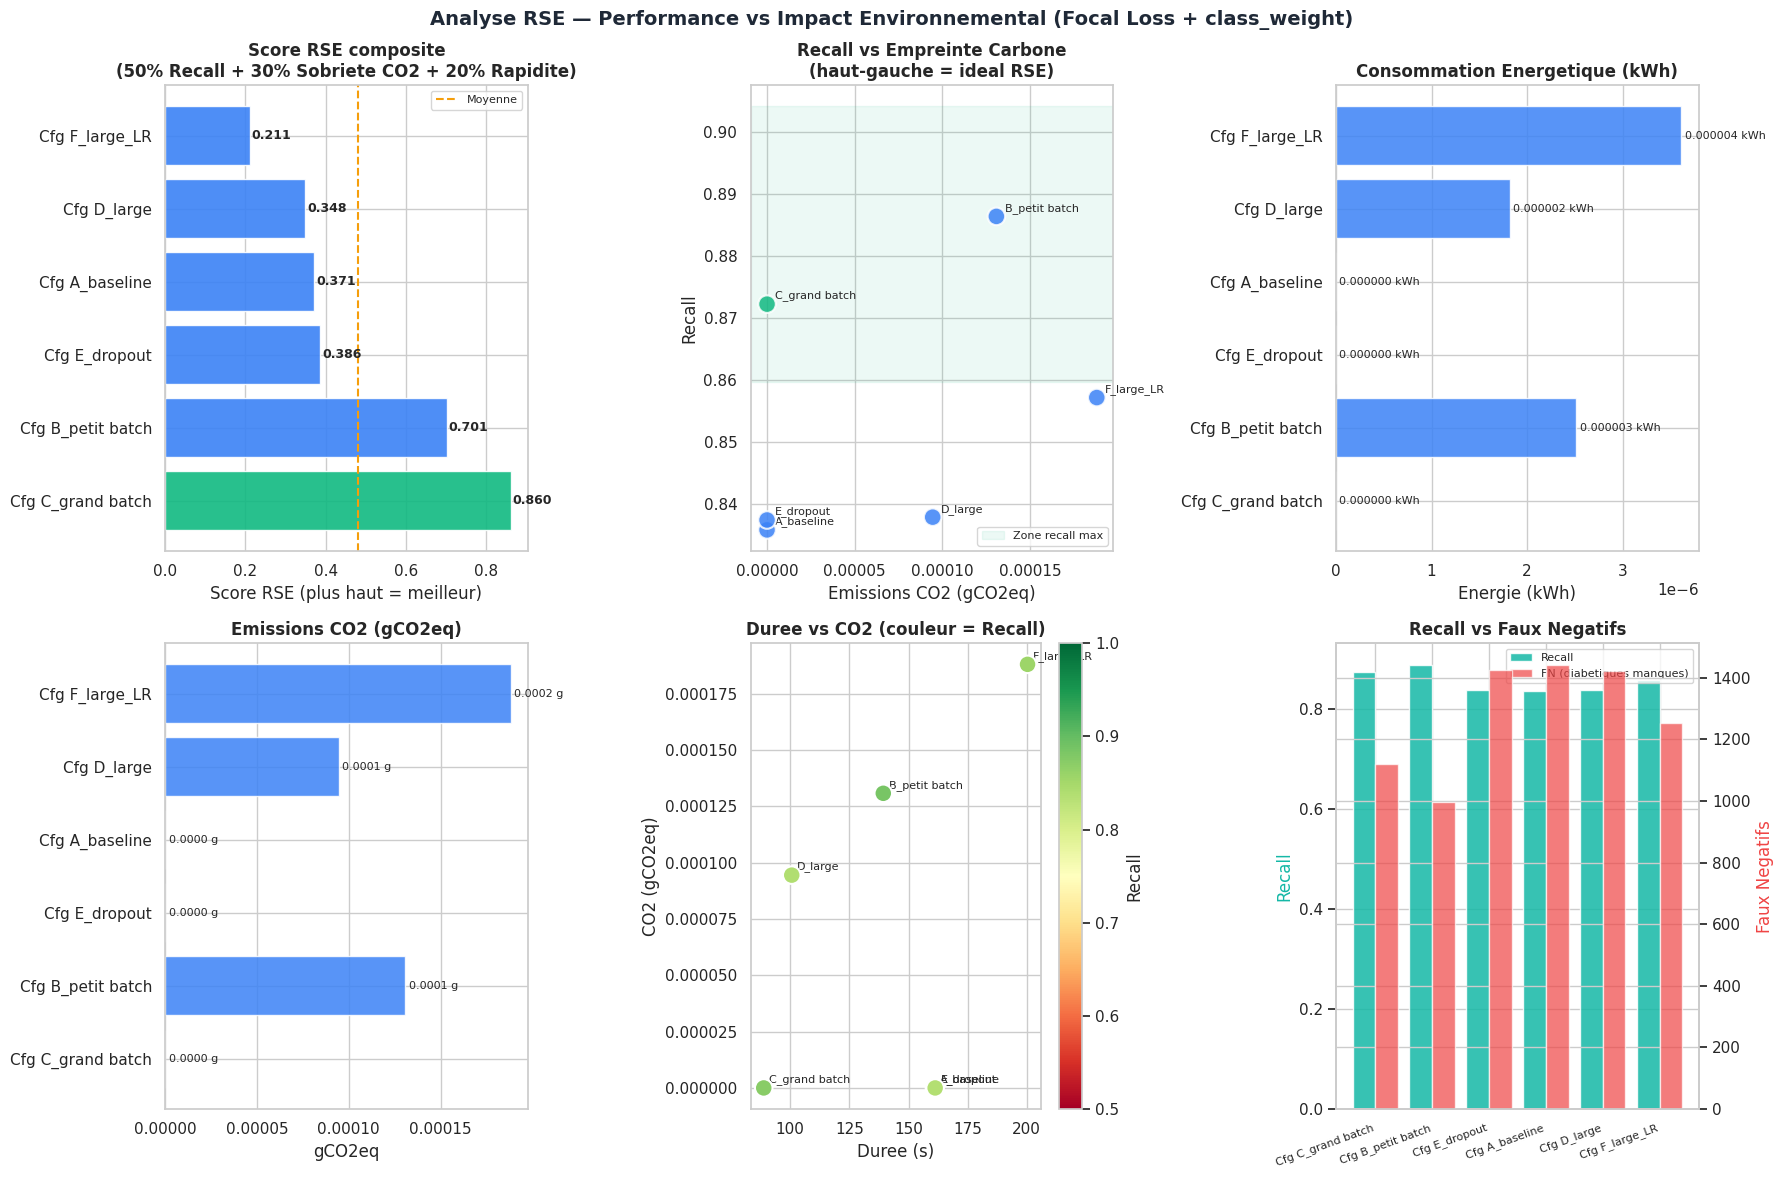

In [139]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

labels = df_rse_sorted['config'].str.replace('Config ', 'Cfg ')
best_cfg = best_rse['config']

# Couleurs : vert pour le meilleur score RSE
bar_colors = [COLORS['green'] if c == best_cfg else COLORS['blue']
              for c in df_rse_sorted['config']]

# ── 1. Score RSE composite ─────────────────────────────────────────────
bars = axes[0,0].barh(labels, df_rse_sorted['score_rse'],
                      color=bar_colors, alpha=0.9, edgecolor='white')
for bar, val in zip(bars, df_rse_sorted['score_rse']):
    axes[0,0].text(val + 0.005, bar.get_y()+bar.get_height()/2,
                   f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
axes[0,0].set_title('Score RSE composite\n(50% Recall + 30% Sobriete CO2 + 20% Rapidite)',
                    fontweight='bold')
axes[0,0].set_xlabel('Score RSE (plus haut = meilleur)')
axes[0,0].axvline(x=df_rse_sorted['score_rse'].mean(), color=COLORS['orange'],
                  lw=1.5, linestyle='--', label='Moyenne')
axes[0,0].legend(fontsize=8)

# ── 2. Scatter Recall vs CO2 (Pareto RSE) ────────────────────────────
scatter_colors = [COLORS['green'] if c == best_cfg else COLORS['blue']
                  for c in df_rse['config']]
axes[0,1].scatter(df_rse['co2_g'], df_rse['recall'],
                  color=scatter_colors, s=160, alpha=0.85,
                  edgecolors='white', linewidth=1.5, zorder=5)
for _, row in df_rse.iterrows():
    axes[0,1].annotate(
        row['config'].replace('Config ', ''),
        (row['co2_g'], row['recall']),
        textcoords='offset points', xytext=(6, 4), fontsize=8)
axes[0,1].set_xlabel('Emissions CO2 (gCO2eq)')
axes[0,1].set_ylabel('Recall')
axes[0,1].set_title('Recall vs Empreinte Carbone\n(haut-gauche = ideal RSE)',
                    fontweight='bold')
axes[0,1].axhspan(df_rse['recall'].max()*0.97, df_rse['recall'].max()*1.02,
                  alpha=0.08, color=COLORS['green'], label='Zone recall max')
axes[0,1].legend(fontsize=8)

# ── 3. Consommation energetique ─────────────────────────────────────
bars2 = axes[0,2].barh(labels, df_rse_sorted['energie_kwh'],
                       color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars2, df_rse_sorted['energie_kwh']):
    axes[0,2].text(val + df_rse_sorted['energie_kwh'].max()*0.01,
                   bar.get_y()+bar.get_height()/2,
                   f'{val:.6f} kWh', va='center', fontsize=8)
axes[0,2].set_title('Consommation Energetique (kWh)', fontweight='bold')
axes[0,2].set_xlabel('Energie (kWh)')

# ── 4. Emissions CO2 par config ──────────────────────────────────────
bars3 = axes[1,0].barh(labels, df_rse_sorted['co2_g'],
                       color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars3, df_rse_sorted['co2_g']):
    axes[1,0].text(val + df_rse_sorted['co2_g'].max()*0.01,
                   bar.get_y()+bar.get_height()/2,
                   f'{val:.4f} g', va='center', fontsize=8)
axes[1,0].set_title('Emissions CO2 (gCO2eq)', fontweight='bold')
axes[1,0].set_xlabel('gCO2eq')

# ── 5. Duree vs CO2 (couleur = Recall) ───────────────────────────────
sc = axes[1,1].scatter(
    df_rse['duree_s'], df_rse['co2_g'],
    c=df_rse['recall'], cmap='RdYlGn', s=160,
    edgecolors='white', linewidth=1.5, vmin=0.5, vmax=1.0, zorder=5)
for _, row in df_rse.iterrows():
    axes[1,1].annotate(row['config'].replace('Config ',''),
                       (row['duree_s'], row['co2_g']),
                       textcoords='offset points', xytext=(4,4), fontsize=8)
plt.colorbar(sc, ax=axes[1,1], label='Recall')
axes[1,1].set_xlabel('Duree (s)')
axes[1,1].set_ylabel('CO2 (gCO2eq)')
axes[1,1].set_title('Duree vs CO2 (couleur = Recall)', fontweight='bold')

# ── 6. Comparaison Recall / FN ───────────────────────────────────────
x = np.arange(len(df_rse_sorted)); w = 0.4
ax6 = axes[1,2]
bars_r = ax6.bar(x - w/2, df_rse_sorted['recall'], w,
                 label='Recall', color=COLORS['teal'], alpha=0.85)
ax6b = ax6.twinx()
bars_fn = ax6b.bar(x + w/2, df_rse_sorted['fn'], w,
                   label='FN (diabetiques manques)', color=COLORS['red'], alpha=0.7)
ax6.set_xticks(x); ax6.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax6.set_ylabel('Recall', color=COLORS['teal'])
ax6b.set_ylabel('Faux Negatifs', color=COLORS['red'])
ax6.set_title('Recall vs Faux Negatifs', fontweight='bold')
lines1, lab1 = ax6.get_legend_handles_labels()
lines2, lab2 = ax6b.get_legend_handles_labels()
ax6.legend(lines1+lines2, lab1+lab2, fontsize=8, loc='upper right')

plt.suptitle('Analyse RSE — Performance vs Impact Environnemental (Focal Loss + class_weight)',
             fontsize=14, fontweight='bold', color=COLORS['dark'])
plt.tight_layout()
plt.show()

In [140]:
# ── Conclusion RSE ────────────────────────────────────────────────────────
print('=== CONCLUSION RSE ===')
print()
print(f'Modele recommande (meilleur compromis RSE) : {best_rse["config"]}')
print(f'  Score RSE      : {best_rse["score_rse"]:.3f} / 1.000')
print(f'  Recall         : {best_rse["recall"]:.4f}  (objectif medical)')
print(f'  AUC-ROC        : {best_rse["auc"]:.4f}')
print(f'  FN (manques)   : {int(best_rse["fn"]):,}')
print(f'  CO2 estime     : {best_rse["co2_g"]:.6f} gCO2eq  (seuil acceptable : 10g)')
print(f'  Energie        : {best_rse["energie_kwh"]:.8f} kWh')
print(f'  Duree          : {best_rse["duree_s"]:.2f}s')
print(f'  RAM delta      : {best_rse["ram_delta_mb"]:.1f} MB')
print()
print('=== TOP 3 RSE ===')
for i, row in enumerate(df_rse_sorted.head(3).itertuples(), 1):
    print(f'{i}. {row.config}')
    print(f'   Score: {row.score_rse:.3f} | Recall: {row.recall:.4f} | CO2: {row.co2_g:.4f}g | Duree: {row.duree_s:.1f}s')
print()
print('=== SYNTHESE RSE ===')
total_co2   = df_rse['co2_g'].sum()
total_kWh   = df_rse['energie_kwh'].sum()
total_duree = df_rse['duree_s'].sum()
print(f'CO2 total (toutes configs) : {total_co2:.4f} gCO2eq')
print(f'Energie totale             : {total_kWh:.8f} kWh')
print(f'Duree totale               : {total_duree:.1f}s ({total_duree/60:.1f} min)')
print()
seuil_ok = best_rse['co2_g'] < 10
print(f'Conformite seuil CO2 (<10g) : {"OK" if seuil_ok else "ATTENTION"}')
recall_ok = best_rse['recall'] >= 0.70
print(f'Conformite recall (>=0.70)  : {"OK" if recall_ok else "ATTENTION"}')

=== CONCLUSION RSE ===

Modele recommande (meilleur compromis RSE) : Config C_grand batch
  Score RSE      : 0.860 / 1.000
  Recall         : 0.8722  (objectif medical)
  AUC-ROC        : 0.8104
  FN (manques)   : 1,121
  CO2 estime     : 0.000000 gCO2eq  (seuil acceptable : 10g)
  Energie        : 0.00000000 kWh
  Duree          : 88.79s
  RAM delta      : 1.6 MB

=== TOP 3 RSE ===
1. Config C_grand batch
   Score: 0.860 | Recall: 0.8722 | CO2: 0.0000g | Duree: 88.8s
2. Config B_petit batch
   Score: 0.701 | Recall: 0.8864 | CO2: 0.0001g | Duree: 139.3s
3. Config E_dropout
   Score: 0.386 | Recall: 0.8375 | CO2: 0.0000g | Duree: 161.3s

=== SYNTHESE RSE ===
CO2 total (toutes configs) : 0.0004 gCO2eq
Energie totale             : 0.00000795 kWh
Duree totale               : 851.3s (14.2 min)

Conformite seuil CO2 (<10g) : OK
Conformite recall (>=0.70)  : OK


## 9. MLOps — Sauvegarde & Tracking

### Artifacts de production
- `model_production.keras` : modèle en float32 (CPU-friendly).
- `scaler_production.pkl` : StandardScaler pour normalisation à prédiction.
- `config_production.json` : features, seuil, metriques (pour webapp).
- `mlops_runs.json` : historique de tous les runs (audit trail).

### Promotion conditionnelle
Un run est "promu" (`promoted=True`) si :
- AUC ≥ 0.75 **ET** Recall ≥ 0.70.

Sinon reste en "staging" (sauvegardé mais pas en prod réelle).

### Versioning
- `best_<timestamp>.keras` : modèles validés archivés.
- Permet rollback facile si un modèle futur régresse.

### Traçabilité
Chaque run log : features, hyperparams, class_weight, focal loss, métriques, CO2, timestamp.
=> Reproductibilité et audit complet pour régulateur / clinique.


---
## 9. MLOps — Sauvegarde & Tracking

### Livrables produits
- modele de production (`model_production.keras`),
- scaler de preprocessing (`scaler_production.pkl`),
- configuration de reference (`config_production.json`),
- historique des runs (`mlops_runs.json`).

### Logique de promotion
Un modele est promu si les seuils minimaux sont atteints (AUC, Recall).
Cela garantit une qualite minimale avant mise a disposition applicative.

### Traçabilite
Chaque run enregistre timestamp, metriques, seuil de decision et meta-donnees de train,
facilitant audit, comparaison temporelle et rollback.


In [141]:
BASE_DIR = Path.cwd()
MLOPS_DIR = BASE_DIR / 'mlops'
MODELS_DIR = MLOPS_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RUNS_FILE = MLOPS_DIR / 'mlops_runs.json'
all_runs = json.loads(RUNS_FILE.read_text(encoding='utf-8')) if RUNS_FILE.exists() else []
ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

AUC_MIN=0.75; RECALL_MIN=0.70
model_to_export = best.get('model')
if model_to_export is None:
    best_model_path = best.get('model_path')
    if not best_model_path:
        raise ValueError('model_path manquant pour exporter le meilleur modele')
    model_to_export = keras.models.load_model(
        best_model_path,
        custom_objects={'loss': focal_loss(2.0, 0.75)}
    )

run_entry = {'timestamp':ts,'config':best['config'],'auc':round(best['auc'],4),
    'recall':round(best['recall'],4),'f1':round(best['f1'],4),
    'precision':round(best['precision'],4),'fn':best['fn'],'fp':best['fp'],
    'seuil':round(best['seuil'],4),'epochs':best['epochs'],
    'input_dim':INPUT_DIM,'feature_names':feature_names,
    'class_weight':{str(k):round(v,4) for k,v in CLASS_WEIGHT.items()},
    'focal_loss':True,'promoted':False}

if best['auc']>=AUC_MIN and best['recall']>=RECALL_MIN:
    model_to_export.save(str(MODELS_DIR / f'best_{ts}.keras'))
    with (MODELS_DIR / f'scaler_{ts}.pkl').open('wb') as f: pickle.dump(scaler,f)
    run_entry['promoted']=True
    print('Modele VALIDE et sauvegarde')
else:
    print(f"NON valide : AUC={best['auc']:.4f}(min {AUC_MIN}) Recall={best['recall']:.4f}(min {RECALL_MIN})")

model_to_export.save(str(MLOPS_DIR / 'model_production.keras'))
with (MLOPS_DIR / 'scaler_production.pkl').open('wb') as f: pickle.dump(scaler,f)
with (MLOPS_DIR / 'config_production.json').open('w', encoding='utf-8') as f:
    json.dump({'feature_names':feature_names,'seuil':best['seuil'],
               'config':best['config'],'recall':best['recall'],'auc':best['auc']},f,indent=2)
all_runs.append(run_entry)
RUNS_FILE.write_text(json.dumps(all_runs, indent=2), encoding='utf-8')
print(f'Production pret dans {MLOPS_DIR}  |  {len(all_runs)} runs loggues')


Modele VALIDE et sauvegarde
Production pret dans /home/jxc/CESI/deep_learning/mlops  |  2 runs loggues
